In [113]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [114]:
df = pd.read_csv('/Users/priya/Documents/Projects/Accident/accident.csv', sep=";")
print(df.columns)

Index(['DATE', 'TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE',
       'ON STREET NAME', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')


In [115]:
df.columns = df.columns.str.lower().str.replace(' ','_')
print(df.columns)

Index(['date', 'time', 'borough', 'zip_code', 'latitude', 'longitude',
       'on_street_name', 'number_of_pedestrians_injured',
       'number_of_pedestrians_killed', 'number_of_cyclist_injured',
       'number_of_cyclist_killed', 'number_of_motorist_injured',
       'number_of_motorist_killed', 'contributing_factor_vehicle_1',
       'contributing_factor_vehicle_2', 'contributing_factor_vehicle_3',
       'contributing_factor_vehicle_4', 'contributing_factor_vehicle_5',
       'collision_id', 'vehicle_type_code_1', 'vehicle_type_code_2',
       'vehicle_type_code_3', 'vehicle_type_code_4', 'vehicle_type_code_5'],
      dtype='object')


In [116]:
print(df['borough'].value_counts())

borough
BROOKLYN         76253
QUEENS           67120
MANHATTAN        48749
BRONX            37709
STATEN ISLAND     8691
Name: count, dtype: int64


## 1 PIVOT_TABLE & PIVOT 


###    Syntax for pivot_table

pd.pivot_table(
    dataset,
    index='...',     can choose the category we want to compare vertically
    columns='...',   can choose another category we want to compare horizontally
    values='...',    can choose the category which are in numeric or count we want to summarize
    aggfunc='...'    how to aggregate (sum, count, mean…) 
)



### 1.1
PIVOT will not work is we have duplicates 

it can work only if the combination of index+ columns is unique

here there are some duplicate values in the index (date)
This works only if each borough has at most one accident per date. there are multiple, pivot() it is throwing an error

In [10]:
pivot_df = df.pivot(
    index='date',          # rows = date
    columns='borough',     # columns = borough
    values='collision_id'  # values = collision id
)


ValueError: Index contains duplicate entries, cannot reshape

### 1.2
here i have tried to display which borough as highest accidents using pivot_table

In [11]:
pd.pivot_table(df, index='borough' ,values='collision_id', aggfunc='count').sort_values(by='collision_id', ascending=False)

,collision_id
borough,
BROOKLYN,76253
QUEENS,67120
MANHATTAN,48749
BRONX,37709
STATEN ISLAND,8691


### 1.3

here i have tried to display no.of accidents for each borough on a particular day using date 
If a borough had no accidents on a date then the cell value is null
then i have sorted the collisions in descending other

In [12]:
pivot_df=df.pivot_table(values='collision_id',index='borough',columns='date',aggfunc='count')
#.sort_values(by='collision_id', ascending=False)

pivot_df['total_collisions'] = pivot_df.sum(axis=1)


pivot_df = pivot_df.sort_values(by='total_collisions', ascending=False)

print(pivot_df)


date           01/01/2018  01/01/2019  01/02/2018  01/02/2019  01/03/2018  \
borough                                                                     
BROOKLYN              109          89         146         100         143   
QUEENS                 89          78         123         122         125   
MANHATTAN              52          44          75          56          64   
BRONX                  43          48          60          51          63   
STATEN ISLAND           8          14          18          20          24   

date           01/03/2019  01/04/2018  01/04/2019  01/05/2018  01/05/2019  \
borough                                                                     
BROOKLYN              101          83         117         163          90   
QUEENS                104          93         124         143          76   
MANHATTAN              64          42          61          75          52   
BRONX                  54          58          65          77          55  

### 1.4 Pivot_table Vs Groupby

#### Pivot Table
can use when our output needs to be in tabular formate with rows & columns, like Excel Pivot.
Reshapes data
Creates 2D tables
Handles duplicates
Supports aggregations



#### GroupBy
can use when we want 1D or simple grouping.
Not meant for reshaping
More flexible for transformations
Usually results in a Series or DataFrame


In [ ]:
total_collisions_df = df.groupby(['borough','date'])['collision_id'].count()

total_collisions_df = total_collisions_df.sort_values(ascending=False)


total_collisions_df = total_collisions_df.to_frame(name='total_collisions')

print(total_collisions_df)

                          total_collisions
borough       date                        
QUEENS        11/15/2018               214
BROOKLYN      11/15/2018               213
              03/22/2018               195
              12/14/2018               184
              06/27/2019               181
...                                    ...
STATEN ISLAND 05/03/2019                 3
              04/28/2019                 3
              07/07/2019                 3
              06/20/2019                 3
              04/11/2019                 2

[3005 rows x 1 columns]


## 2 CROSSTAB

### syntax 
pd.crosstab(
    index,                      # row categories
    columns,                    # column categories
    values=None,                # optional numeric column
    aggfunc=None,               # aggregation function
    margins=False,              # add totals row/column
    normalize=False             # percentages
)



### 2.1 
here i want to compare which vehicle_type involved in accidents for each borough

### Crosstab Vs Pivot_table 

#### Crosstab
  this is mainly used to summarize frquency or to count categorical variables
  it performes counts by default

#### Pivot_table
  this is mainly used to summarize, aggregate, reshape the data
  it performes sum by default 
  it can also performe some aggregations like ( Sum,Mean,Max,Min,etc )  

to do above analysis i created a list of all vehicle_types as 'vehicle_cols'
here 'vehicle_cols' is a list which it can not be used in crosstab , crosstab only accepts columns
so i have melted the list to column and saved to melted_df 

In [ ]:

vehicle_cols = [
    'vehicle_type_code_1', 'vehicle_type_code_2',
    'vehicle_type_code_3', 'vehicle_type_code_4',
    'vehicle_type_code_5'
]

melted_df = df.melt(
    id_vars=['borough'],
    value_vars=vehicle_cols,
    var_name='vehicle_number',
    value_name='vehicle_type'
)


ct = pd.crosstab(melted_df['borough'], melted_df['vehicle_type'], margins=True)
print(ct)


vehicle_type   (ceme  00  013  1  12 Pa  15 Pa  18 WH  2 DOO  2 TON  2- to  \
borough                                                                      
BRONX              0   0    0  0      0      0      0      0      0      0   
BROOKLYN           1   0    0  0      0      1      1      0      0      1   
MANHATTAN          0   0    1  0      0      0      0      1      0      0   
QUEENS             0   1    0  1      1      0      0      0      1      0   
STATEN ISLAND      0   0    0  0      0      0      0      0      0      0   
All                1   1    1  1      1      1      1      1      1      1   

vehicle_type   ...  util  utili  van  van t  wagon  white  work  omm  ï¿½MBU  \
borough        ...                                                              
BRONX          ...     0      1   20      0      1      0     1     0       0   
BROOKLYN       ...     0      4   43      0      2      1     0     0       1   
MANHATTAN      ...     1      0   43      0      0 

### 2.2
here i want to check which borough has the most truck accidents
by using above vehicle_type 
and i sorted them to save only Truck related vehicle_type

In [64]:

truck_accidents = df_vehicles[df_vehicles['vehicle_type'].str.contains('Truck', case=False, na=False)]

truck_crosstab = pd.crosstab(truck_accidents['borough'], truck_accidents['vehicle_type'])
truck_crosstab['Total'] = truck_crosstab.sum(axis=1)
truck_crosstab.sort_values('Total', ascending=False)



vehicle_type,Armored Truck,Beverage Truck,Box Truck,FIRE TRUCK,PICK-UP TRUCK,Pick-up Truck,TRUCK,Tow Truck,Tow Truck / Wrecker,Tractor Truck Diesel,Tractor Truck Gasoline,Truck,truck,Total
borough,,,,,,,,,,,,,,
BROOKLYN,27,29,2446,8,819,3310,52,4,136,788,188,6,6,7819
MANHATTAN,55,34,3669,3,645,2473,22,4,93,388,73,1,4,7464
QUEENS,17,19,1498,5,829,3222,11,1,75,580,63,1,4,6325
BRONX,12,18,1132,4,443,1745,5,2,48,629,73,1,0,4112
STATEN ISLAND,1,1,41,0,160,564,1,0,4,17,3,0,1,793


### 2.3
Here i compaired does manhattan have more taxi-related accidents than brooklyn 

In [ ]:

taxi_accidents = df_vehicles[df_vehicles['vehicle_type'].str.contains('Taxi', case=False, na=False)]

taxi_crosstab = pd.crosstab(taxi_accidents['borough'], taxi_accidents['vehicle_type'])
taxi_crosstab['Total'] = taxi_crosstab.sum(axis=1)
taxi_crosstab.loc[['MANHATTAN', 'BROOKLYN'], 'Total']


borough
MANHATTAN    14046
BROOKLYN      2947
Name: Total, dtype: int64

### 2.4

here i want to check what percentage of motorcycles accidents involved in Queens 

In [52]:

motorcycle_accidents = df_vehicles[df_vehicles['vehicle_type'].str.contains('Motorcycle', case=False, na=False)]


motorcycle_crosstab = pd.crosstab(motorcycle_accidents['borough'], motorcycle_accidents['vehicle_type'])

total_accidents = pd.crosstab(df_vehicles['borough'], df_vehicles['vehicle_type'])

percentage_queens_motorcycle = (motorcycle_crosstab.loc['QUEENS'].sum() / total_accidents.loc['QUEENS'].sum()) * 100
percentage_queens_motorcycle


np.float64(0.4366670717381618)

## 3 Melt & Cut

### Melt
    it can be used when we have many columns and want to represent them as rows
    it is used to reshape a datase from wide format to lng format

### Cut
    it is used to bin or categorize continuous numerical data into groups
    we can used them to create groups , helps in segmentation and aggregation

### 3.1 
here i want to categorize accidents by severity as 'low','medium', 'high'

In [ ]:

df_accidents = pd.DataFrame({
    'Borough': ['Manhattan', 'Brooklyn', 'Queens'],
    'Accidents': [2, 8, 15]
})

bins = [0, 5, 10, 20]
labels = ['Low', 'Medium', 'High']

df_accidents['Accident_Level'] = pd.cut(df_accidents['Accidents'], bins=bins, labels=labels)

print(df_accidents)


     Borough  Accidents Accident_Level
0  Manhattan          2            Low
1   Brooklyn          8         Medium
2     Queens         15           High


### 3.2
 here i have aggregated all injuries into one column 'total_injured'
 and i have used Cut() to categorize accidents by severity and visualized overall distribution of injury level

/var/folders/ql/72ttndnx3rl_77y4q5x_g21c0000gn/T/ipykernel_21199/3740824417.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=injury_counts.index, y=injury_counts.values, palette='Reds')


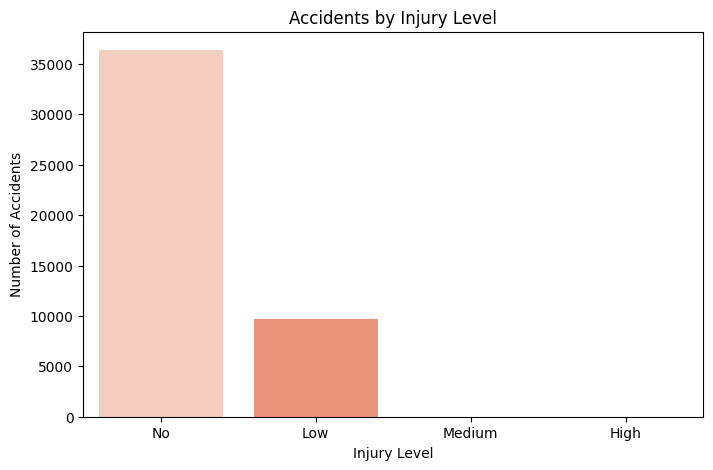

In [78]:


df['total_injured'] = df['number_of_pedestrians_injured'] + df['number_of_cyclist_injured'] + df['number_of_motorist_injured']


bins = [0, 1, 30, 60, 100]  
labels = ['No', 'Low', 'Medium', 'High']
df['injury_level'] = pd.cut(df['total_injured'], bins=bins, labels=labels)


injury_counts = df['injury_level'].value_counts().sort_index()


plt.figure(figsize=(8,5))
sns.barplot(x=injury_counts.index, y=injury_counts.values, palette='Reds')
plt.title('Accidents by Injury Level')
plt.ylabel('Number of Accidents')
plt.xlabel('Injury Level')
plt.show()



### 3.3
here i visualized overall injury levels across each boroughs

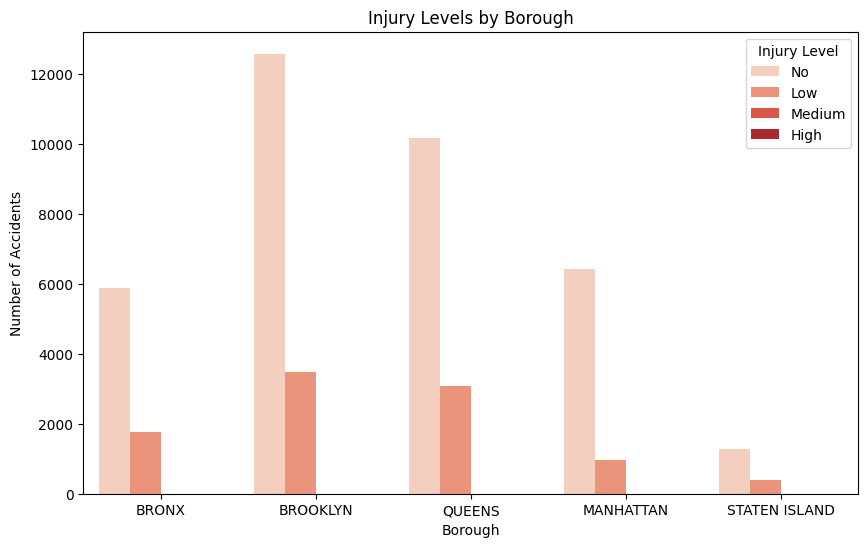

In [71]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='borough', hue='injury_level', palette='Reds')
plt.title('Injury Levels by Borough')
plt.ylabel('Number of Accidents')
plt.xlabel('Borough')
plt.legend(title='Injury Level')
plt.show()


## 4 Pandas Functions for Data analysis
following i will mention some pandas functions used in each phase of data analysis

### 4.1 Exploring 
    
df.head( )   - shows first 5 rows to quickly see the data
df.info()   - shows column types and number of non-null values
df.describe  - gives count, mean, min, max etc for numeric columns
df.isnull().sum  -  counts missing values in each column 

In [112]:
df.describe()

,zip_code,latitude,longitude,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,collision_id,total_injured,total_injuries,total_deaths
count,238452.000000,231544.000000,231544.000000,238522.000000,238522.000000,238522.000000,238522.000000,238522.000000,238522.000000,2.385220e+05,238522.000000,238522.000000,238522.000000
mean,10865.578838,40.656873,-73.797699,0.054523,0.000532,0.023482,0.000084,0.178076,0.000310,4.008044e+06,0.256081,0.256081,0.000927
std,546.056571,1.632850,2.961521,0.237834,0.023250,0.152835,0.009157,0.587479,0.017848,1.084693e+05,0.631125,0.631125,0.030699
min,10000.000000,0.000000,-74.253930,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.511951e+06,0.000000,0.000000,0.000000
25%,10452.000000,40.666750,-73.973860,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.913739e+06,0.000000,0.000000,0.000000
50%,11208.000000,40.717007,-73.922770,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.006476e+06,0.000000,0.000000,0.000000
75%,11354.000000,40.765715,-73.864890,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.102648e+06,0.000000,0.000000,0.000000
max,11697.000000,40.912884,0.000000,6.000000,2.000000,3.000000,1.000000,21.000000,2.000000,4.195347e+06,22.000000,22.000000,2.000000


### 4.2 Filtering Data 

filtering function uses boolean indexing displayes rows based on condition

In [88]:
# Accidents in Manhattan
manhattan_accidents = df[df['borough'] == 'MANHATTAN']
print(manhattan_accidents)

# Accidents with pedestrian injuries
ped_injuries = df[df['number_of_pedestrians_injured'] > 0]
print(ped_injuries)


              date   time    borough  zip_code   latitude  longitude  \
16      09/19/2018   8:30  MANHATTAN   10036.0        NaN        NaN   
20      08/11/2019   0:07  MANHATTAN   10010.0  40.738550 -73.980430   
28      08/09/2019  10:50  MANHATTAN   10027.0  40.805590 -73.948280   
33      08/05/2019  15:25  MANHATTAN   10026.0        NaN        NaN   
42      09/07/2018  17:00  MANHATTAN   10018.0        NaN        NaN   
...            ...    ...        ...       ...        ...        ...   
238470  01/22/2018  20:20  MANHATTAN   10024.0  40.788315 -73.976510   
238481  01/10/2018  19:00  MANHATTAN   10009.0  40.723150 -73.979560   
238485  01/25/2018  18:14  MANHATTAN   10019.0  40.768307 -73.986630   
238501  01/09/2018  12:15  MANHATTAN   10029.0  40.790367 -73.949776   
238508  01/26/2018  11:20  MANHATTAN   10019.0  40.762062 -73.983635   

                          on_street_name  number_of_pedestrians_injured  \
16                                   NaN                    

### 4.3 Aggregation & Grouping 
groupby() 
count() 
sum()

#### 4.3.1
accidents by borough

In [91]:
accidents_by_borough = df.groupby('borough')['collision_id'].count()
print(accidents_by_borough)


borough
BRONX            37709
BROOKLYN         76253
MANHATTAN        48749
QUEENS           67120
STATEN ISLAND     8691
Name: collision_id, dtype: int64


#### 4.3.2
total injuries per borough

In [92]:
injuries_by_borough = df.groupby('borough')[['number_of_pedestrians_injured',
                                             'number_of_cyclist_injured',
                                             'number_of_motorist_injured']].sum()
print(injuries_by_borough)


               number_of_pedestrians_injured  number_of_cyclist_injured  \
borough                                                                   
BRONX                                   2299                        597   
BROOKLYN                                4412                       2211   
MANHATTAN                               2750                       1659   
QUEENS                                  3229                       1067   
STATEN ISLAND                            315                         67   

               number_of_motorist_injured  
borough                                    
BRONX                                7642  
BROOKLYN                            14962  
MANHATTAN                            4365  
QUEENS                              13612  
STATEN ISLAND                        1894  


## 4.4 Pivot_table 
    
    number of collisions per borough per date

In [ ]:

pivot_df = df.pivot_table(values='collision_id', index='borough', columns='date', aggfunc='count')
print(pivot_df)


date           01/01/2018  01/01/2019  01/02/2018  01/02/2019  01/03/2018  \
borough                                                                     
BRONX                  43          48          60          51          63   
BROOKLYN              109          89         146         100         143   
MANHATTAN              52          44          75          56          64   
QUEENS                 89          78         123         122         125   
STATEN ISLAND           8          14          18          20          24   

date           01/03/2019  01/04/2018  01/04/2019  01/05/2018  01/05/2019  \
borough                                                                     
BRONX                  54          58          65          77          55   
BROOKLYN              101          83         117         163          90   
MANHATTAN              64          42          61          75          52   
QUEENS                104          93         124         143          76  

## 4.5 Data cleaning 

fillna()  - replace missing values
dropna()  - remove rows with missing values

In [101]:

df['on_street_name'] = df['on_street_name'].fillna('Unknown')

df = df.dropna(subset=['borough'])
print(df)


              date   time   borough  zip_code   latitude  longitude  \
0       09/26/2018  12:12     BRONX   10454.0  40.808987 -73.911316   
1       09/25/2018  16:30  BROOKLYN   11236.0  40.636005 -73.912510   
2       08/22/2019  19:30    QUEENS   11101.0  40.755490 -73.939530   
3       09/23/2018  13:10    QUEENS   11367.0        NaN        NaN   
4       08/20/2019  22:40     BRONX   10468.0  40.868336 -73.901270   
...            ...    ...       ...       ...        ...        ...   
238517  01/20/2018  15:00    QUEENS   11436.0  40.685356 -73.797230   
238518  01/04/2018  14:00     BRONX   10452.0  40.845180 -73.914170   
238519  01/20/2018  13:05     BRONX   10462.0  40.831210 -73.850876   
238520  01/29/2018  17:45    QUEENS   11377.0  40.757250 -73.904854   
238521  01/23/2018  16:38  BROOKLYN   11211.0  40.710197 -73.958430   

                          on_street_name  number_of_pedestrians_injured  \
0                                Unknown                              0 

## 4.6  Sorting
sort_values() - sort by column 

In [106]:
df['total_injuries'] = (df['number_of_pedestrians_injured'] +
                        df['number_of_cyclist_injured'] +
                        df['number_of_motorist_injured'])

top_injury_collisions = df.sort_values(by='total_injuries', ascending=False).head(10)

print(top_injury_collisions)

              date   time        borough  zip_code   latitude  longitude  \
197735  04/06/2018   7:30       BROOKLYN   11225.0  40.659405 -73.950500   
131904  11/16/2018  12:20          BRONX   10457.0  40.845642 -73.902110   
17119   06/10/2019  10:00         QUEENS   11434.0  40.675312 -73.777145   
50817   08/06/2018   0:35      MANHATTAN   10027.0  40.807148 -73.943985   
182488  04/30/2018   9:09          BRONX   10461.0  40.849560 -73.834010   
21389   06/07/2019   9:50  STATEN ISLAND   10301.0  40.602135 -74.114876   
25552   06/07/2019  12:55       BROOKLYN   11207.0  40.662920 -73.890625   
96470   07/14/2018   1:50         QUEENS   11433.0  40.690830 -73.787060   
105027  02/09/2019   7:29          BRONX   10457.0  40.837654 -73.899970   
53978   08/03/2018  14:30       BROOKLYN   11233.0  40.673080 -73.911240   

                          on_street_name  number_of_pedestrians_injured  \
197735  NOSTRAND AVENUE                                               0   
131904  EAST 

## 4.7 Visualization
   
   ### 4.7.1 accidents by borough
   
   countplot()  - counts occurrences of eeach category
   value_counts()  - get frequency of each category

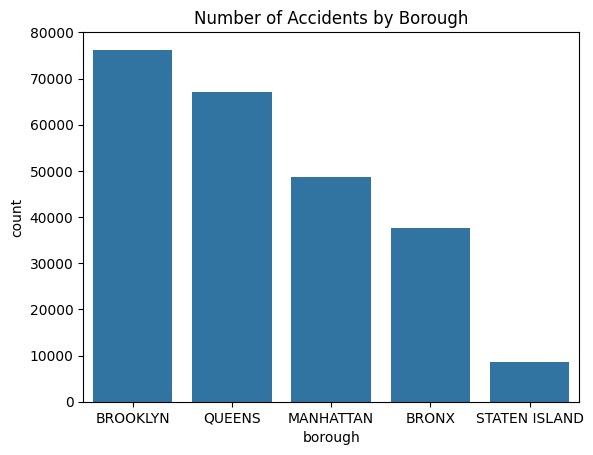

In [107]:
sns.countplot(data=df, x='borough', order=df['borough'].value_counts().index)
plt.title("Number of Accidents by Borough")
plt.show()


### 4.7.2 injuries over time 
    
    groupby() - aggregate by date
    sum()  - total injuries per day
    plot() - line chart

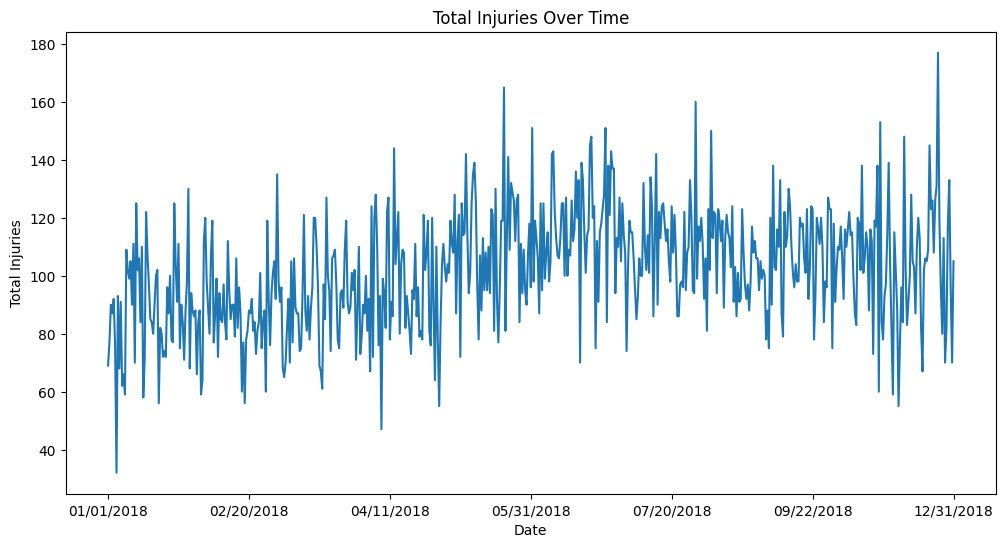

In [108]:
injuries_by_date = df.groupby('date')['total_injuries'].sum()
injuries_by_date.plot(kind='line', figsize=(12,6))
plt.title("Total Injuries Over Time")
plt.xlabel("Date")
plt.ylabel("Total Injuries")
plt.show()


### 4.7.3 heatmap of correlation
    
    corr() - correlation matrix
    heatmap() - visualize correlation 

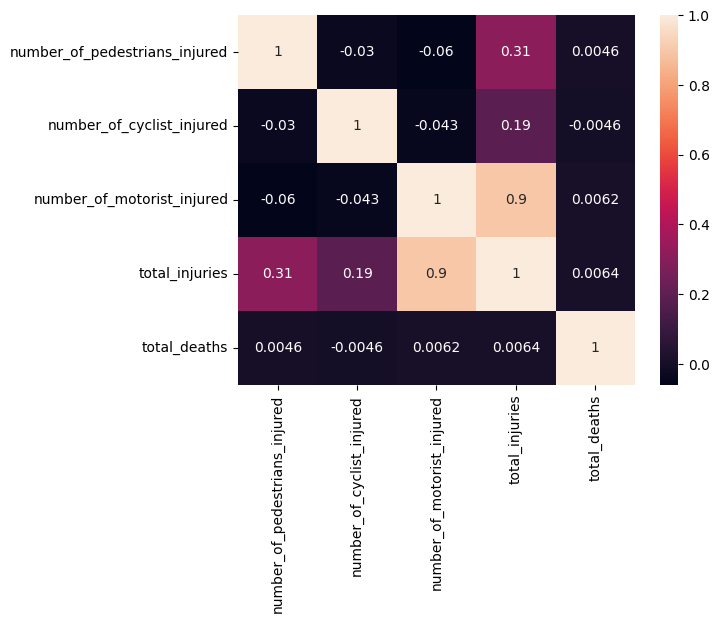

In [109]:
sns.heatmap(df[['number_of_pedestrians_injured','number_of_cyclist_injured','number_of_motorist_injured','total_injuries','total_deaths']].corr(), annot=True)
plt.show()
